# Processed-feature exploratory data analysis

This notebook examines the snapshot-level feature table produced by `scripts/extract_features.py`. It covers dataset shape and schema, data quality, split/condition/bearing coverage, feature distributions, correlations, and degradation trends against remaining useful life (RUL).

> Observations from the same bearing are a time series, not independent samples. Use bearing-level/grouped splits during modeling to avoid leakage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")
RANDOM_STATE = 42

In [2]:
# Work whether Jupyter starts in the repository root or in notebooks/.
search_roots = [Path.cwd(), *Path.cwd().parents]
data_path = next(
    (root / "data" / "processed" / "features.parquet" for root in search_roots
     if (root / "data" / "processed" / "features.parquet").exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError("Could not find data/processed/features.parquet from the current directory.")

df = pd.read_parquet(data_path)
print(f"Loaded {data_path.resolve()}")
print(f"{len(df):,} rows x {df.shape[1]:,} columns")
df.head()

Loaded /mnt/c/Users/chris/OneDrive/Desktop/Python Projects/MLOps-RUL/data/processed/features.parquet
38,848 rows x 30 columns


,split,condition,bearing,elapsed_time_seconds,file_index,rms_horiz,kurtosis_horiz,skewness_horiz,crest_factor_horiz,fft_band_0_horiz,fft_band_1_horiz,fft_band_2_horiz,fft_band_3_horiz,fft_band_4_horiz,fft_band_5_horiz,fft_band_6_horiz,fft_band_7_horiz,rms_vert,kurtosis_vert,skewness_vert,crest_factor_vert,fft_band_0_vert,fft_band_1_vert,fft_band_2_vert,fft_band_3_vert,fft_band_4_vert,fft_band_5_vert,fft_band_6_vert,fft_band_7_vert,rul_seconds
0,Training_set,1,Bearing1_1,0,1,0.5617,-0.1315,-0.004711,3.578,32.92,54.4,262.3,43.61,3.653,1.021,4.613,1.409,0.4358,-0.03508,0.002713,3.651,4.915,35.13,40.26,57.42,21.78,28.51,47.88,7.223,28020
1,Training_set,1,Bearing1_1,10,2,0.5351,-0.08465,-0.02579,3.579,40.48,53.31,230.6,32.19,3.512,1.103,3.864,1.526,0.421,0.1506,0.07738,3.958,5.643,36.01,40.91,47.2,21.08,25.55,41.83,8.609,28010
2,Training_set,1,Bearing1_1,20,3,0.5312,0.03339,-0.005016,3.579,37.09,50.58,224.2,38.67,2.411,1.077,5.381,1.751,0.4256,-0.06155,-0.02439,3.722,4.842,29.61,35.91,57.84,17.84,25.37,53.65,6.831,28000
3,Training_set,1,Bearing1_1,30,4,0.5548,0.04342,-0.08017,3.442,35.9,49.02,256,42.27,2.936,1.205,4.891,1.79,0.4455,-0.1133,-0.00819,3.591,4.753,35.6,43.34,62.41,20.07,30.26,49.32,8.331,27990
4,Training_set,1,Bearing1_1,40,5,0.5667,-0.1855,-0.03419,3.118,37.82,45.15,274.5,43.17,3.026,1.448,4.323,1.619,0.4238,-0.03482,0.08121,3.239,5.689,28.74,35.59,56.78,19.33,31.44,43.07,9.441,27980


## 1. Dataset overview and feature inventory

In [3]:
metadata_cols = [c for c in ["split", "condition", "bearing", "elapsed_time_seconds", "file_index"] if c in df]
target_col = "rul_seconds"
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in metadata_cols + [target_col]]
time_feature_cols = [c for c in feature_cols if not c.startswith("fft_band_")]
fft_feature_cols = [c for c in feature_cols if c.startswith("fft_band_")]

overview = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "engineered features": len(feature_cols),
    "time-domain features": len(time_feature_cols),
    "frequency-domain features": len(fft_feature_cols),
    "splits": df["split"].nunique(),
    "conditions": df["condition"].nunique(),
    "bearings": df["bearing"].nunique(),
    "memory (MiB)": df.memory_usage(deep=True).sum() / 2**20,
}, name="value").to_frame()
display(overview)
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str), "non_null": df.notna().sum().values, "unique": df.nunique(dropna=False).values}))

,value
rows,3.885e+04
columns,30
engineered features,24
time-domain features,8
frequency-domain features,16
splits,3
conditions,3
bearings,17
memory (MiB),9.687


,column,dtype,non_null,unique
split,split,str,38848,3
condition,condition,int64,38848,3
bearing,bearing,str,38848,17
elapsed_time_seconds,elapsed_time_seconds,int64,38848,2803
file_index,file_index,int64,38848,2803
rms_horiz,rms_horiz,float64,38848,24889
kurtosis_horiz,kurtosis_horiz,float64,38848,24889
skewness_horiz,skewness_horiz,float64,38848,24889
crest_factor_horiz,crest_factor_horiz,float64,38848,24889
fft_band_0_horiz,fft_band_0_horiz,float64,38848,24889


In [4]:
print("Metadata:", metadata_cols)
print("Target:", target_col)
print("Time-domain features:", time_feature_cols)
print("Frequency-domain features:", fft_feature_cols)

Metadata: ['split', 'condition', 'bearing', 'elapsed_time_seconds', 'file_index']
Target: rul_seconds
Time-domain features: ['rms_horiz', 'kurtosis_horiz', 'skewness_horiz', 'crest_factor_horiz', 'rms_vert', 'kurtosis_vert', 'skewness_vert', 'crest_factor_vert']
Frequency-domain features: ['fft_band_0_horiz', 'fft_band_1_horiz', 'fft_band_2_horiz', 'fft_band_3_horiz', 'fft_band_4_horiz', 'fft_band_5_horiz', 'fft_band_6_horiz', 'fft_band_7_horiz', 'fft_band_0_vert', 'fft_band_1_vert', 'fft_band_2_vert', 'fft_band_3_vert', 'fft_band_4_vert', 'fft_band_5_vert', 'fft_band_6_vert', 'fft_band_7_vert']


## 2. Data quality checks

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
key_cols = [c for c in ["split", "bearing", "file_index"] if c in df]
quality = pd.Series({
    "missing cells": int(df.isna().sum().sum()),
    "rows with missing values": int(df.isna().any(axis=1).sum()),
    "infinite numeric cells": int(np.isinf(df[numeric_cols].to_numpy()).sum()),
    "duplicate rows": int(df.duplicated().sum()),
    "duplicate snapshot keys": int(df.duplicated(key_cols).sum()),
    "negative RUL values": int((df[target_col] < 0).sum()),
}, name="count").to_frame()
display(quality)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing.gt(0)].rename("missing_count").to_frame() if missing.gt(0).any() else pd.DataFrame({"result": ["No missing values"]}))

,count
missing cells,0
rows with missing values,0
infinite numeric cells,0
duplicate rows,0
duplicate snapshot keys,0
negative RUL values,0


,result
0,No missing values


## 3. Split, condition, and bearing coverage

In [6]:
split_condition = pd.crosstab(df["split"], df["condition"], margins=True)
bearing_summary = (df.groupby(["split", "condition", "bearing"], observed=True)
    .agg(snapshots=("file_index", "size"), first_file=("file_index", "min"), last_file=("file_index", "max"), run_hours=("elapsed_time_seconds", lambda x: (x.max() - x.min()) / 3600), min_rul_hours=(target_col, lambda x: x.min() / 3600), max_rul_hours=(target_col, lambda x: x.max() / 3600))
    .reset_index())
display(split_condition)
display(bearing_summary)

condition,1,2,3,All
split,,,,
Test_set,9047,4560,352,13959
Training_set,3674,1708,2152,7534
Validation_Set,10973,5948,434,17355
All,23694,12216,2938,38848


,split,condition,bearing,snapshots,first_file,last_file,run_hours,min_rul_hours,max_rul_hours
0,Test_set,1,Bearing1_3,1802,1,1802,5.003,1.592,6.594
1,Test_set,1,Bearing1_4,1139,1,1139,3.161,0.8028,3.964
2,Test_set,1,Bearing1_5,2302,1,2302,6.392,0.4472,6.839
3,Test_set,1,Bearing1_6,2302,1,2302,6.392,0.4056,6.797
4,Test_set,1,Bearing1_7,1502,1,1502,4.169,2.103,6.272
5,Test_set,2,Bearing2_3,1202,1,1202,3.336,2.092,5.428
6,Test_set,2,Bearing2_4,612,1,612,1.697,0.3861,2.083
7,Test_set,2,Bearing2_5,2002,1,2002,5.558,0.8583,6.417
8,Test_set,2,Bearing2_6,572,1,572,1.586,0.3583,1.944
9,Test_set,2,Bearing2_7,172,1,172,0.475,0.1611,0.6361


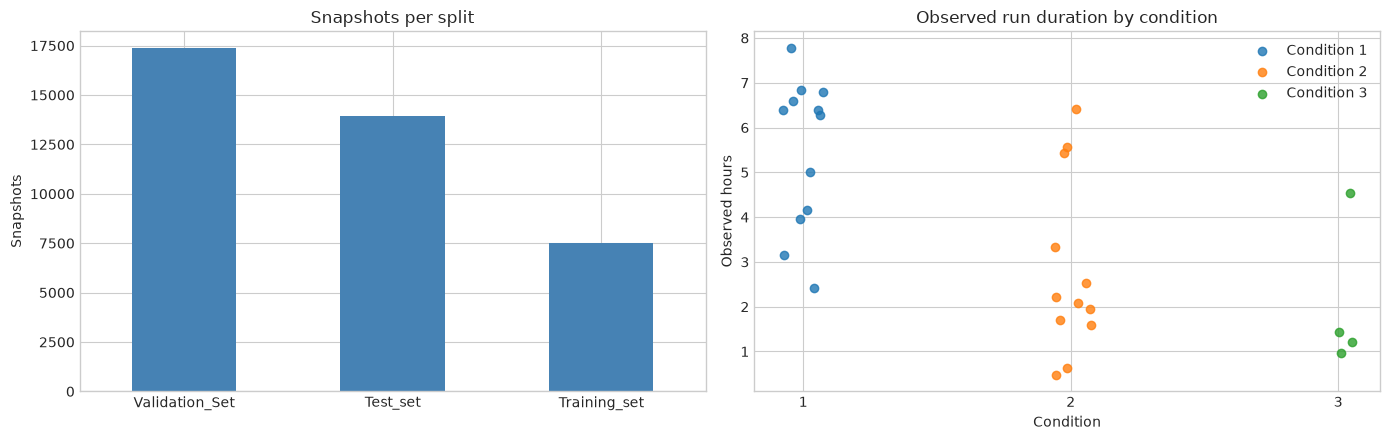

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
df["split"].value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="Snapshots per split", xlabel="", ylabel="Snapshots")
axes[0].tick_params(axis="x", rotation=0)

for condition, group in bearing_summary.groupby("condition"):
    axes[1].scatter(group["condition"] + np.random.default_rng(RANDOM_STATE + int(condition)).uniform(-0.08, 0.08, len(group)), group["run_hours"], label=f"Condition {condition}", alpha=0.8)
axes[1].set(title="Observed run duration by condition", xlabel="Condition", ylabel="Observed hours", xticks=sorted(df["condition"].unique()))
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Numeric summaries and distributions
The plots clip each feature at its 99.5th percentile for readability; the underlying data is not modified. This keeps late-life spikes from compressing most observations into a narrow band.

In [8]:
summary = df[feature_cols + [target_col]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary["skew"] = df[feature_cols + [target_col]].skew()
display(summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
rms_horiz,3.885e+04,0.4624,0.6589,0.03927,0.2188,0.2519,0.2936,0.3463,0.4028,0.8654,3.098,14.25,9.752
kurtosis_horiz,3.885e+04,1.455,6.256,-1.197,-0.1684,-0.06765,0.0993,0.3171,0.9349,4.339,26.31,412.8,18.03
skewness_horiz,3.885e+04,-0.06577,0.2794,-14.41,-1.011,-0.3749,-0.1023,-0.03109,0.02735,0.1235,0.3142,3.047,-10.54
crest_factor_horiz,3.885e+04,4.622,1.651,2.319,3.222,3.406,3.762,4.166,4.868,7.086,12.67,31.67,4.197
fft_band_0_horiz,3.885e+04,309.8,"3,641",0.4538,16.03,21.78,32.62,44.31,67.33,673.1,"3,767",2.568e+05,45.33
fft_band_1_horiz,3.885e+04,166.3,"1,617",0.01446,6.91,8.323,13.66,24.53,42.64,114.6,"2,363",6.371e+04,19.07
fft_band_2_horiz,3.885e+04,82.87,591.7,0.1133,2.329,4.778,11.98,17.26,30.63,146.8,886.6,1.597e+04,14.94
fft_band_3_horiz,3.885e+04,53.8,454,0.1062,3.76,5.211,9.786,13.52,21.17,48.27,356.5,1.251e+04,16.49
fft_band_4_horiz,3.885e+04,20.95,196.3,0.2041,0.9816,1.569,2.76,4.501,6.385,10.6,150,"7,026",17.08
fft_band_5_horiz,3.885e+04,16.59,169.9,0.2011,0.736,1.13,1.986,2.585,3.246,9.495,127.9,"7,553",18.55


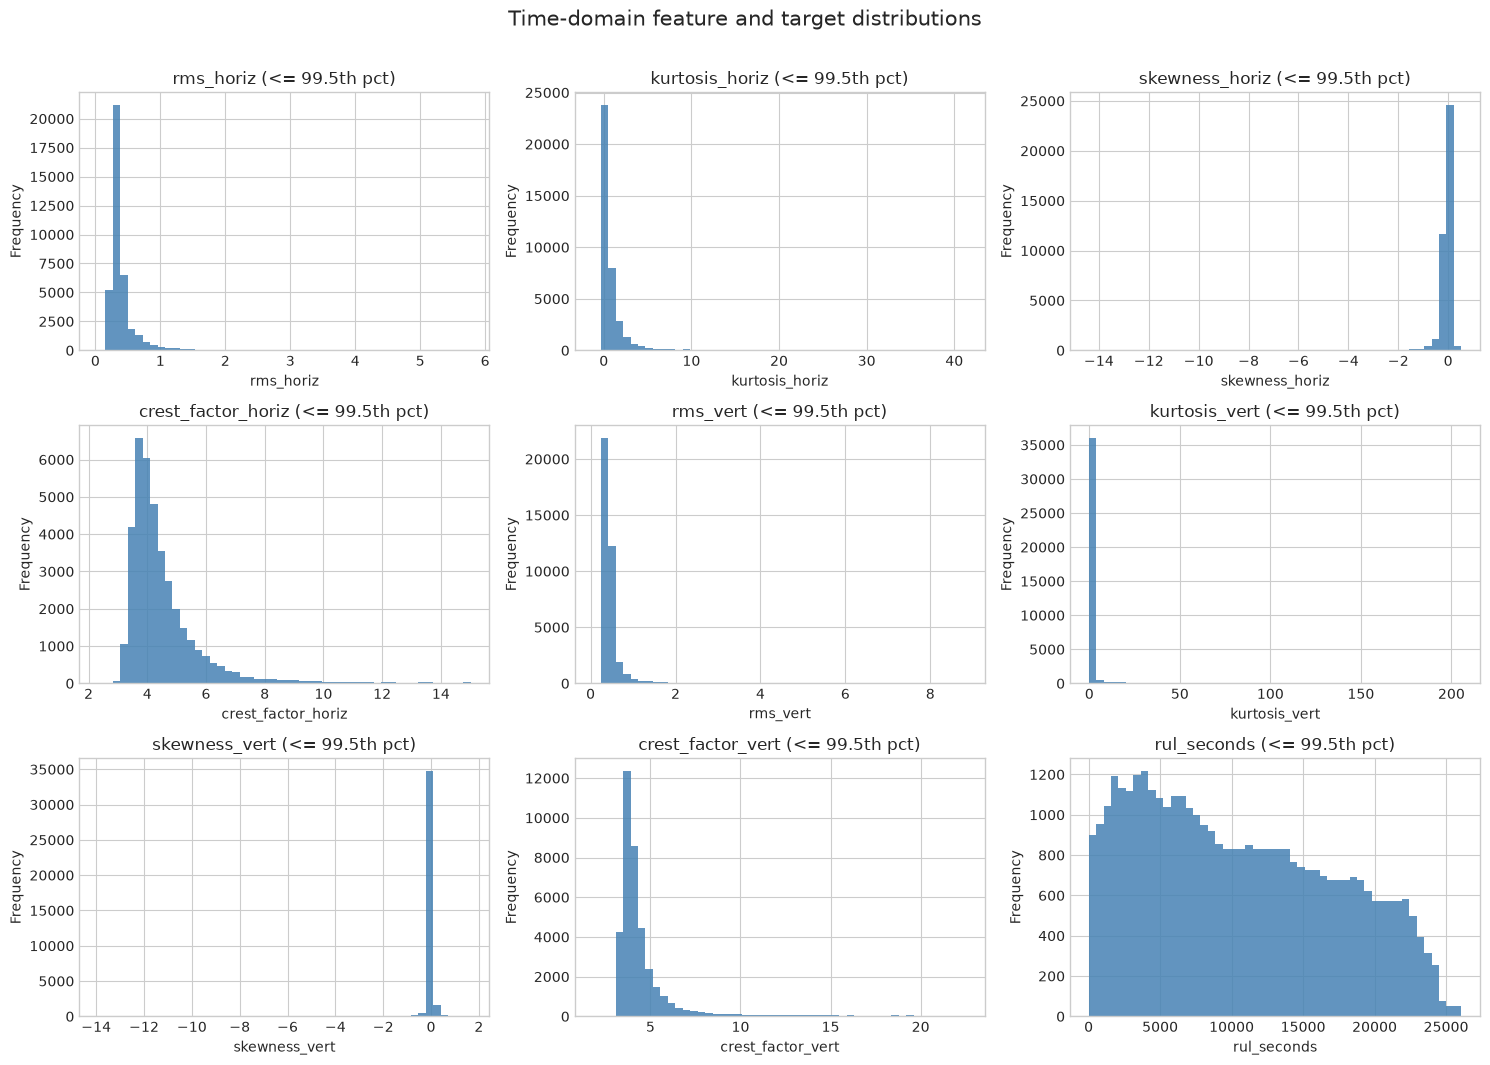

In [9]:
plot_cols = time_feature_cols + [target_col]
ncols = 3
nrows = int(np.ceil(len(plot_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
for ax, col in zip(np.ravel(axes), plot_cols):
    upper = df[col].quantile(0.995)
    df.loc[df[col].le(upper), col].plot.hist(bins=50, ax=ax, color="steelblue", alpha=0.85)
    ax.set_title(f"{col} (<= 99.5th pct)")
    ax.set_xlabel(col)
for ax in np.ravel(axes)[len(plot_cols):]:
    ax.remove()
fig.suptitle("Time-domain feature and target distributions", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

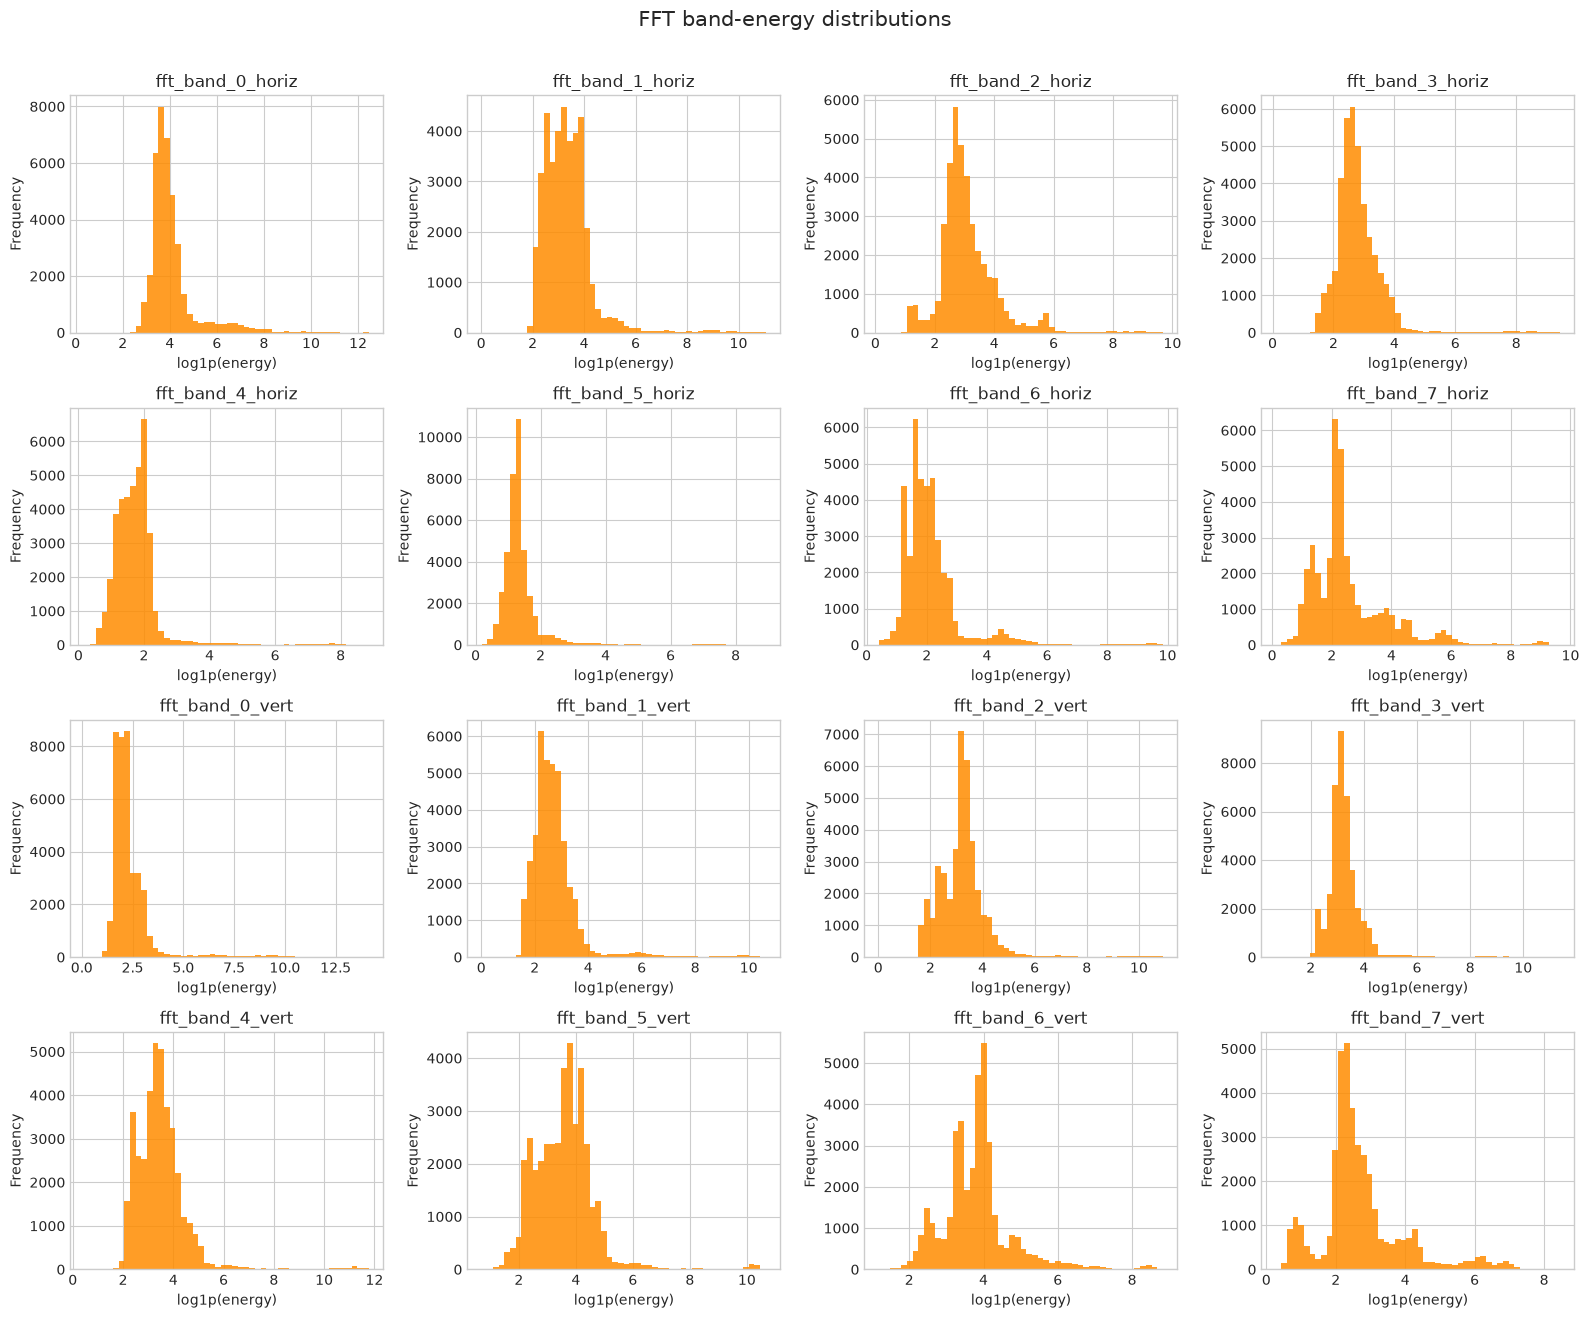

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, col in zip(axes.ravel(), fft_feature_cols):
    # log1p reveals the strongly right-skewed FFT-energy distributions.
    np.log1p(df[col].clip(lower=0)).plot.hist(bins=50, ax=ax, color="darkorange", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("log1p(energy)")
for ax in axes.ravel()[len(fft_feature_cols):]:
    ax.remove()
fig.suptitle("FFT band-energy distributions", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature behavior by operating condition

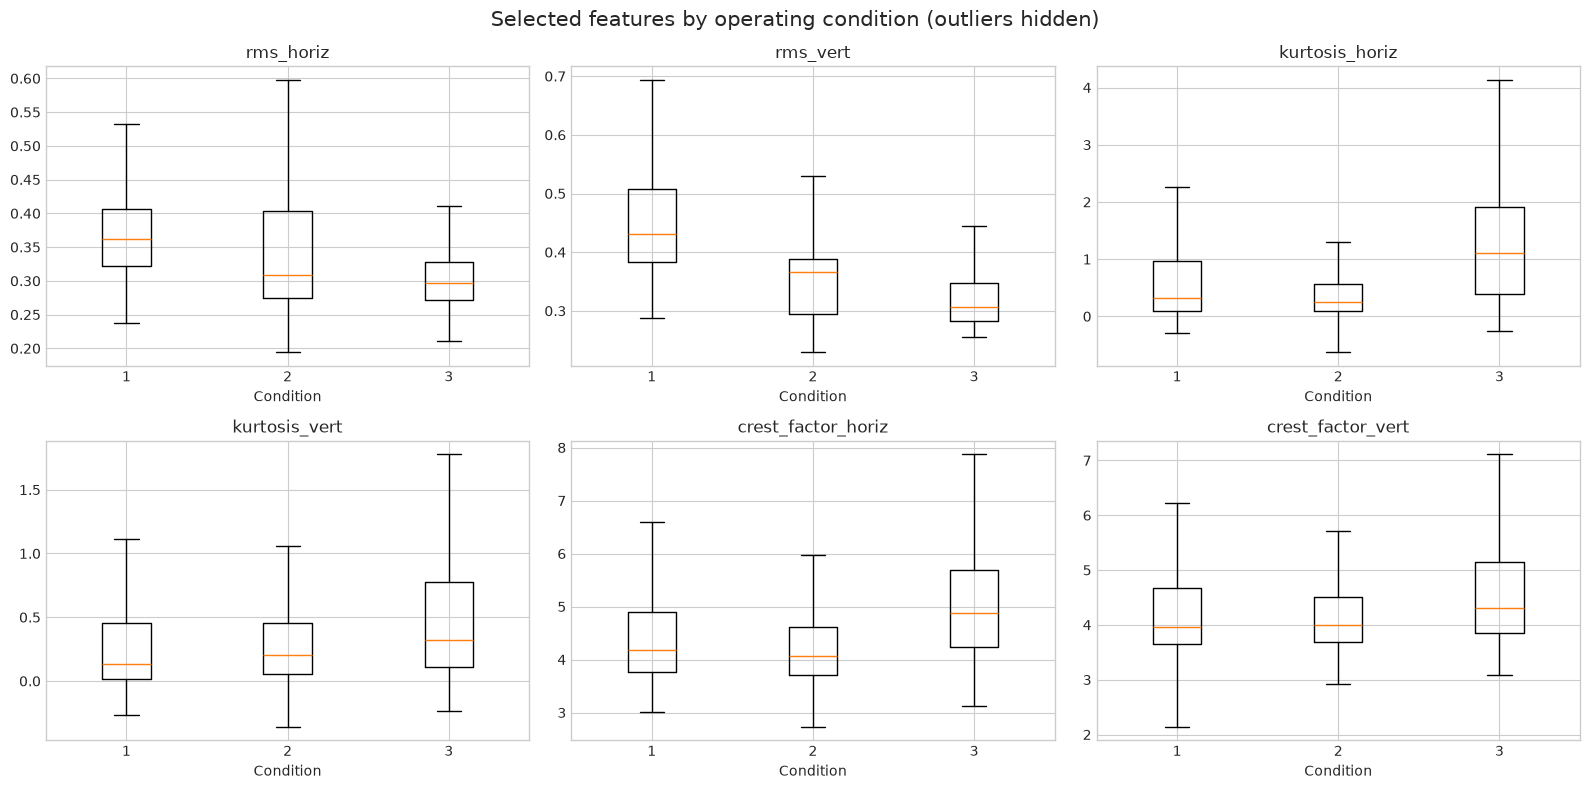

In [11]:
condition_features = [c for c in ["rms_horiz", "rms_vert", "kurtosis_horiz", "kurtosis_vert", "crest_factor_horiz", "crest_factor_vert"] if c in df]
plot_sample = df.sample(min(15_000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), condition_features):
    groups = [plot_sample.loc[plot_sample["condition"].eq(c), col].clip(upper=df[col].quantile(0.995)) for c in sorted(df["condition"].unique())]
    ax.boxplot(groups, tick_labels=sorted(df["condition"].unique()), showfliers=False)
    ax.set(title=col, xlabel="Condition")
for ax in axes.ravel()[len(condition_features):]:
    ax.remove()
fig.suptitle("Selected features by operating condition (outliers hidden)", fontsize=15)
plt.tight_layout()
plt.show()

## 6. Correlation structure
Pearson correlation highlights linear relationships. High feature-to-feature correlation can indicate redundancy; target correlation is descriptive only and does not establish predictive value or causality.

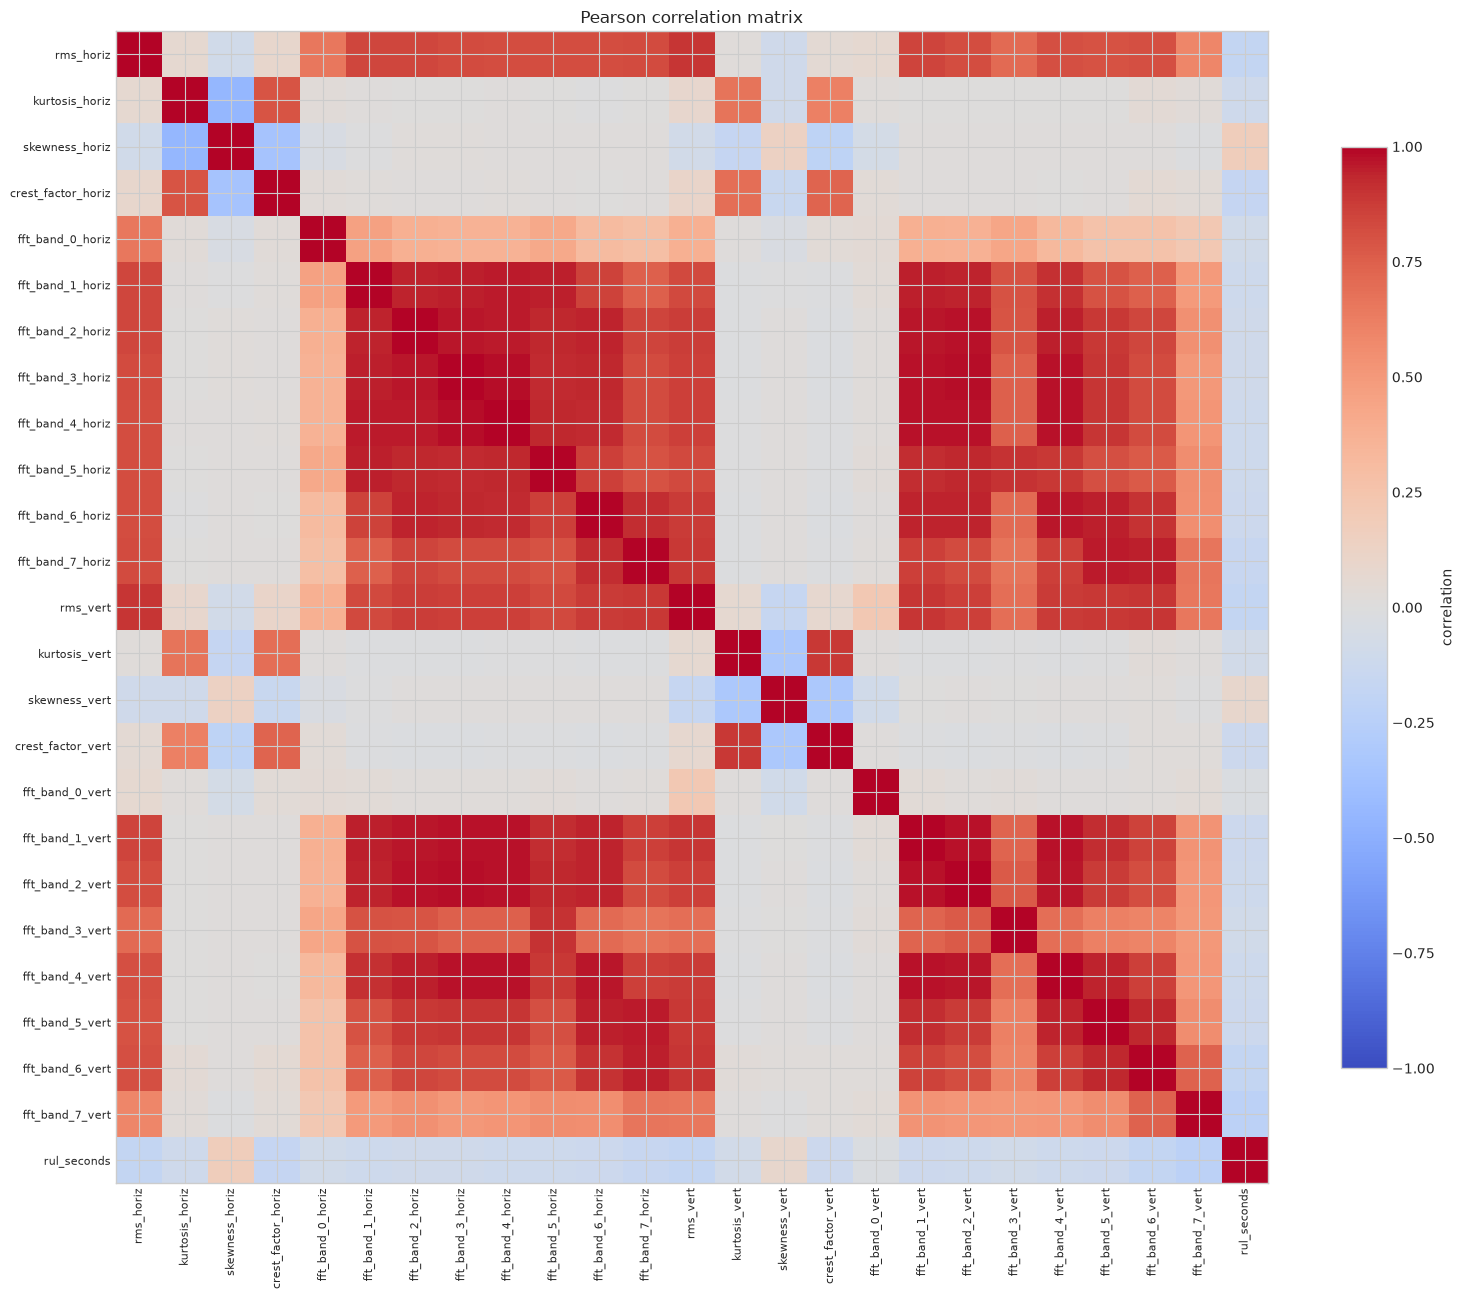

In [12]:
corr = df[feature_cols + [target_col]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(16, 13))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
ax.set_title("Pearson correlation matrix")
fig.colorbar(image, ax=ax, shrink=0.8, label="correlation")
plt.tight_layout()
plt.show()

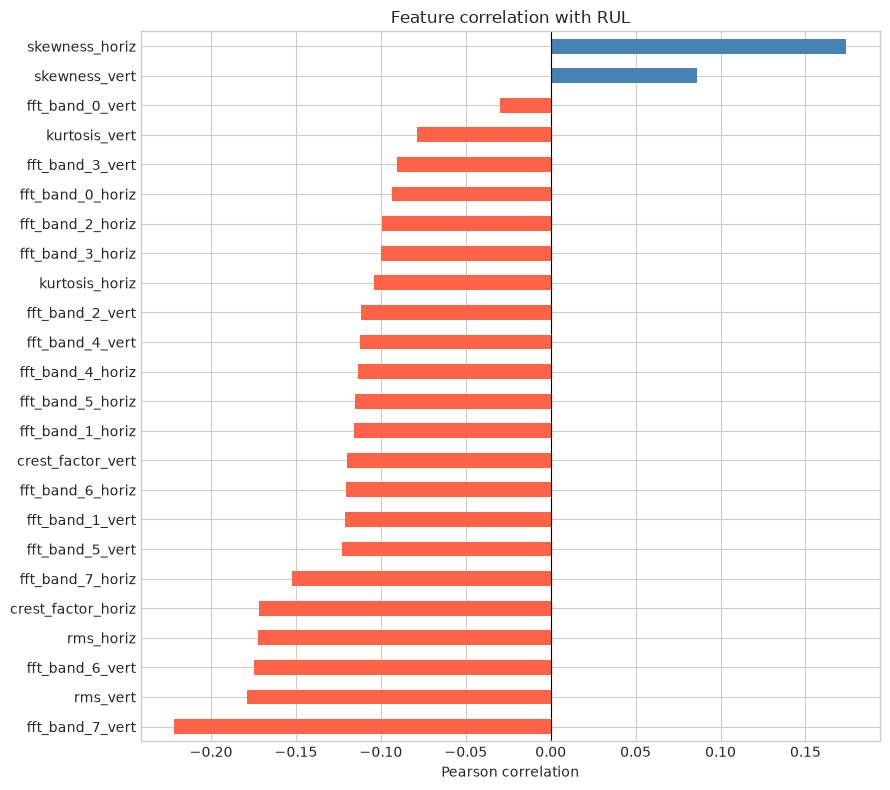

,absolute_correlation_with_rul
fft_band_7_vert,0.2217
rms_vert,0.1787
fft_band_6_vert,0.1745
skewness_horiz,0.1741
rms_horiz,0.1725
crest_factor_horiz,0.1718
fft_band_7_horiz,0.1523
fft_band_5_vert,0.1227
fft_band_1_vert,0.1209
fft_band_6_horiz,0.1204


In [13]:
target_corr = corr[target_col].drop(target_col).sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
target_corr.plot.barh(ax=ax, color=np.where(target_corr.ge(0), "steelblue", "tomato"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Feature correlation with RUL", xlabel="Pearson correlation", ylabel="")
plt.tight_layout()
plt.show()
display(target_corr.abs().sort_values(ascending=False).rename("absolute_correlation_with_rul").to_frame())

In [14]:
feature_corr = corr.loc[feature_cols, feature_cols]
upper_triangle = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
strong_pairs = (upper_triangle.stack().rename("correlation").reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
strong_pairs["absolute_correlation"] = strong_pairs["correlation"].abs()
display(strong_pairs.sort_values("absolute_correlation", ascending=False).head(15))

,feature_1,feature_2,correlation,absolute_correlation
186,fft_band_3_horiz,fft_band_2_vert,0.9801,0.9801
176,fft_band_3_horiz,fft_band_4_horiz,0.9776,0.9776
426,fft_band_1_vert,fft_band_2_vert,0.9749,0.9749
185,fft_band_3_horiz,fft_band_1_vert,0.9738,0.9738
188,fft_band_3_horiz,fft_band_4_vert,0.9735,0.9735
210,fft_band_4_horiz,fft_band_2_vert,0.9729,0.9729
162,fft_band_2_horiz,fft_band_2_vert,0.972,0.972
428,fft_band_1_vert,fft_band_4_vert,0.9719,0.9719
212,fft_band_4_horiz,fft_band_4_vert,0.9713,0.9713
209,fft_band_4_horiz,fft_band_1_vert,0.9702,0.9702


## 7. Degradation trends over bearing life
Raw snapshot plots are noisy, so the following charts use a centered rolling median. Each condition is represented by its bearing with the most observed snapshots.

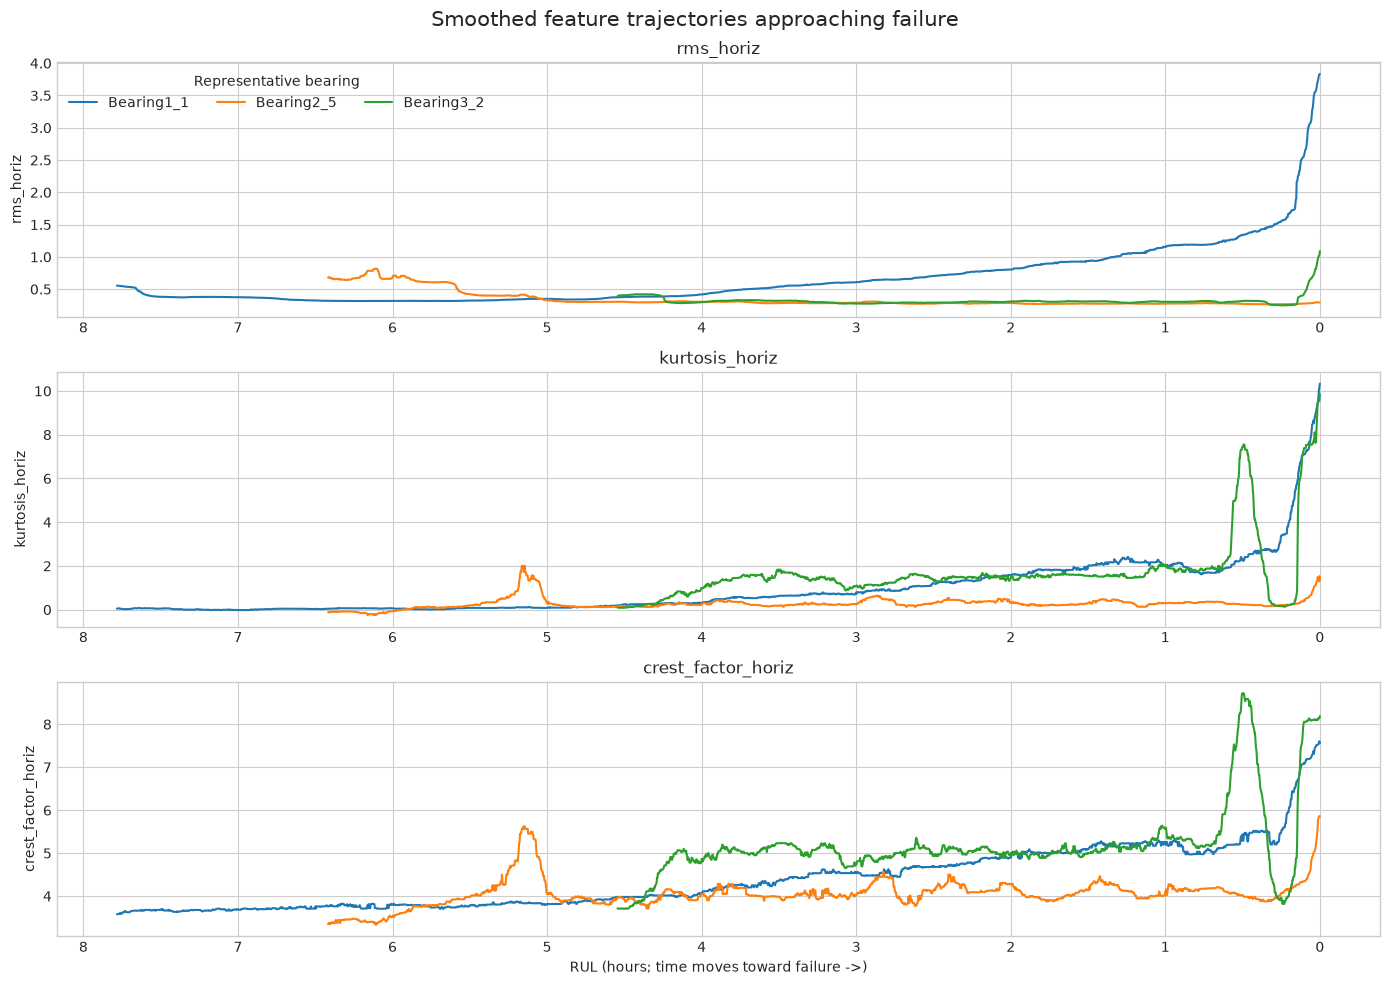

In [15]:
representative = (bearing_summary.sort_values("snapshots").groupby("condition", observed=True).tail(1)
                  .sort_values("condition")["bearing"].tolist())
trend_features = [c for c in ["rms_horiz", "kurtosis_horiz", "crest_factor_horiz"] if c in df]
fig, axes = plt.subplots(len(trend_features), 1, figsize=(14, 10), sharex=False)
for ax, feature in zip(np.atleast_1d(axes), trend_features):
    for bearing in representative:
        run = df.loc[df["bearing"].eq(bearing)].sort_values("file_index").copy()
        window = max(5, min(101, len(run) // 30))
        ax.plot(run[target_col] / 3600, run[feature].rolling(window, center=True, min_periods=1).median(), label=bearing, linewidth=1.5)
    ax.set(title=feature, ylabel=feature)
    ax.invert_xaxis()
axes[-1].set_xlabel("RUL (hours; time moves toward failure ->)")
axes[0].legend(title="Representative bearing", ncols=3)
fig.suptitle("Smoothed feature trajectories approaching failure", fontsize=15)
plt.tight_layout()
plt.show()

## 8. Modeling-oriented checks and takeaways

After running the notebook, use the tables and plots above to record the main findings here. In particular, check:

- whether missing, infinite, duplicate, or physically invalid values require preprocessing;
- which features are heavily skewed and may benefit from `log1p` or robust scaling;
- which feature pairs are redundant enough to warrant regularization or feature selection;
- whether feature baselines differ by operating condition;
- whether feature trajectories change consistently as RUL approaches zero;
- whether truncated test runs have a different RUL range from full-run data; and
- whether evaluation uses group-aware splitting by bearing rather than random row splitting.